**Deep Learning Assignment**

Can AI Save Lives?
Building an Intelligent Clinical Early Warning System

Student: Muhammad Shamas

ID: 22F-BSAI-91

**Install Required Libraries**

In [3]:
!pip install transformers
!pip install datasets
!pip install bertviz
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 9.3 MB/s eta 0:00:00



**Import Libraries**



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Bidirectional

**Load Dataset**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/dataset/Dataset.csv'
)

df.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [7]:
print(df.shape)

df.info()

print(df.columns)


(1552210, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1552210 non-null  int64  
 1   Hour              1552210 non-null  int64  
 2   HR                1398811 non-null  float64
 3   O2Sat             1349474 non-null  float64
 4   Temp              525226 non-null   float64
 5   SBP               1325945 non-null  float64
 6   MAP               1358940 non-null  float64
 7   DBP               1065656 non-null  float64
 8   Resp              1313875 non-null  float64
 9   EtCO2             57636 non-null    float64
 10  BaseExcess        84145 non-null    float64
 11  HCO3              65028 non-null    float64
 12  FiO2              129365 non-null   float64
 13  pH                107573 non-null   float64
 14  PaCO2             86301 non-null    float64
 15  SaO2              53561 non-null   

Unnecessary Columns


In [8]:
df = df.drop(
    columns=[
        'Unnamed: 0',
        'Patient_ID'
    ]
)

Missing Values Check


In [9]:
missing = df.isnull().sum()

missing.sort_values(ascending=False).head(20)

,0
Bilirubin_direct,1549220
Fibrinogen,1541968
TroponinI,1537429
Bilirubin_total,1529069
Alkalinephos,1527269
AST,1527027
Lactate,1510764
PTT,1506511
SaO2,1498649
EtCO2,1494574


High Missing Columns Remove


In [10]:
missing_percent = df.isnull().mean()*100

missing_percent.sort_values(
    ascending=False
)

,0
Bilirubin_direct,99.807371
Fibrinogen,99.340167
TroponinI,99.047745
Bilirubin_total,98.509158
Alkalinephos,98.393194
AST,98.377604
Lactate,97.329872
PTT,97.055875
SaO2,96.549372
EtCO2,96.286843


Remove above 80% columns


In [11]:
cols_to_drop = missing_percent[
    missing_percent > 80
].index

df = df.drop(
    columns=cols_to_drop
)

Check Remaining Columns

In [12]:
print(df.shape)

df.head()


(1552210, 15)


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,68.54,0,NaN,NaN,-0.02,2,0
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,68.54,0,NaN,NaN,-0.02,4,0
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,68.54,0,NaN,NaN,-0.02,5,0


Mean Imputation

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy='mean'
)

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

Features & Target

In [14]:
X = df.drop(
    'SepsisLabel',
    axis=1
)

y = df['SepsisLabel']

Class Distribution Check

In [15]:
print(y.value_counts())

print(
    y.value_counts(normalize=True)
)

SepsisLabel
0.0    1524294
1.0      27916
Name: count, dtype: int64
SepsisLabel
0.0    0.982015
1.0    0.017985
Name: proportion, dtype: float64


In [16]:
print(y.value_counts())
print(y.value_counts(normalize=True))

SepsisLabel
0.0    1524294
1.0      27916
Name: count, dtype: int64
SepsisLabel
0.0    0.982015
1.0    0.017985
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1241768, 14)
(310442, 14)


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5091571096450406), 1: np.float64(27.801191062553173)}


In [19]:
print(X_train.shape)
print(X_test.shape)
print(class_weights)

(1241768, 14)
(310442, 14)
{0: np.float64(0.5091571096450406), 1: np.float64(27.801191062553173)}


DNN Train


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

Model Function

In [21]:
def build_dnn():

    model = Sequential([
        Dense(128, activation='relu', input_shape=(14,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    return model

Adam Model

In [22]:
adam_model = build_dnn()

adam_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train

In [23]:
history_adam = adam_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.7201 - loss: 0.6109 - val_accuracy: 0.7479 - val_loss: 0.5689
Epoch 2/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7434 - loss: 0.5792 - val_accuracy: 0.7210 - val_loss: 0.5723
Epoch 3/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7493 - loss: 0.5748 - val_accuracy: 0.7229 - val_loss: 0.5933
Epoch 4/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7460 - loss: 0.5725 - val_accuracy: 0.7630 - val_loss: 0.5474
Epoch 5/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7477 - loss: 0.5711 - val_accuracy: 0.7381 - val_loss: 0.5650
Epoch 6/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7451 - loss: 0.5686 - val_accuracy: 0.7405 - val_loss: 0.5683
Epoch 7/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7457 - loss: 0.5654 - val_accuracy: 0.7354 - val_loss: 0.5791
Epoch 8/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7468 - loss: 0

In [24]:
from sklearn.metrics import classification_report

pred = adam_model.predict(X_test)

pred = (pred > 0.5).astype(int)

print(classification_report(y_test, pred))

9702/9702 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.71      0.83    304859
         1.0       0.04      0.72      0.08      5583

    accuracy                           0.71    310442
   macro avg       0.52      0.72      0.46    310442
weighted avg       0.98      0.71      0.82    310442



SGD model

In [25]:
sgd_model = build_dnn()

sgd_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.7218 - loss: 0.6234 - val_accuracy: 0.7494 - val_loss: 0.6008
Epoch 2/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7456 - loss: 0.5980 - val_accuracy: 0.7295 - val_loss: 0.6023
Epoch 3/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7398 - loss: 0.5923 - val_accuracy: 0.7648 - val_loss: 0.5690
Epoch 4/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7418 - loss: 0.5877 - val_accuracy: 0.7358 - val_loss: 0.5854
Epoch 5/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7419 - loss: 0.5848 - val_accuracy: 0.7278 - val_loss: 0.5898
Epoch 6/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7420 - loss: 0.5810 - val_accuracy: 0.7438 - val_loss: 0.5707
Epoch 7/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7480 - loss: 0.5798 - val_accuracy: 0.7476 - val_loss: 0.5757
Epoch 8/10
3881/3881 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7461 - loss: 0

Prediction


In [28]:
pred_sgd = sgd_model.predict(X_test)

pred_sgd = (pred_sgd > 0.5).astype(int)

9702/9702 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step


Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_sgd))

              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84    304859
         1.0       0.04      0.68      0.08      5583

    accuracy                           0.73    310442
   macro avg       0.52      0.71      0.46    310442
weighted avg       0.98      0.73      0.83    310442



Loss Curve

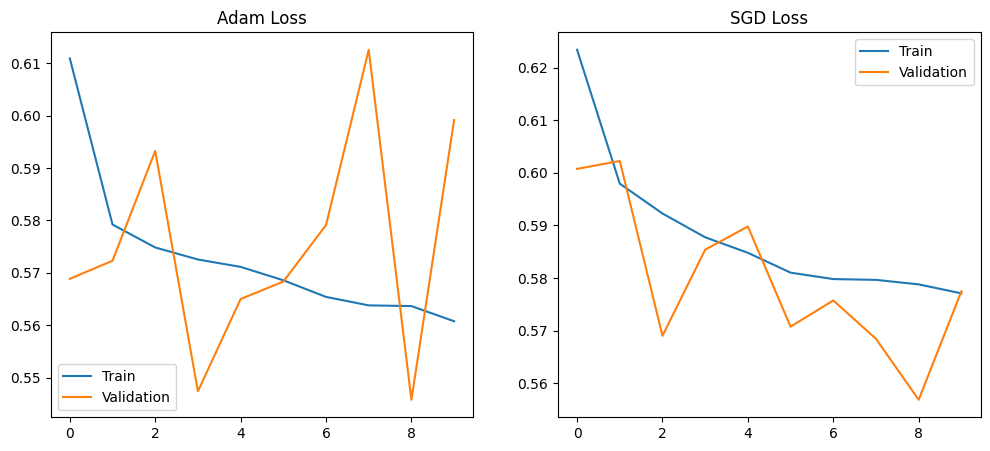

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_adam.history['loss'])
plt.plot(history_adam.history['val_loss'])
plt.title("Adam Loss")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_sgd.history['loss'])
plt.plot(history_sgd.history['val_loss'])
plt.title("SGD Loss")
plt.legend(['Train','Validation'])

plt.show()

Confusion Matrix

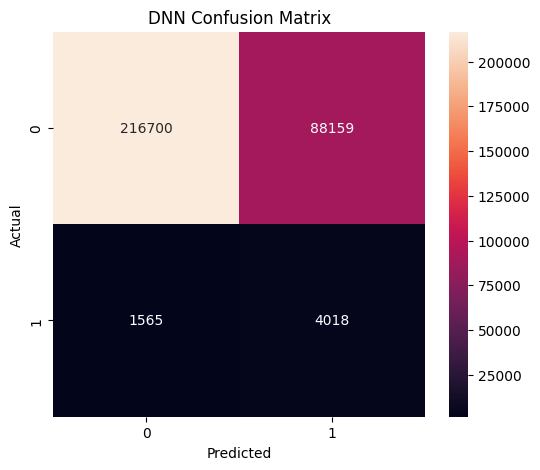

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Generation 2 (LSTM / GRU / Bi-LSTM)**

In [32]:
df_small = df.sample(
    n=100000,
    random_state=42
)

print(df_small.shape)

(100000, 15)


Sort by Time

In [33]:
df_small = df_small.sort_values(
    by=['Hour']
)

Features & Target

In [34]:
X = df_small.drop(
    'SepsisLabel',
    axis=1
)

y = df_small['SepsisLabel']

Normalize

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

Sequence Creation

In [37]:
import numpy as np

timesteps = 12

X_seq = []
y_seq = []

for i in range(len(X)-timesteps):

    X_seq.append(
        X[i:i+timesteps]
    )

    y_seq.append(
        y.iloc[i+timesteps]
    )

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(99988, 12, 14)
(99988,)


Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

print(X_train_seq.shape)

(79990, 12, 14)


In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_seq)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_seq
)

class_weights_seq = {
    0: weights[0],
    1: weights[1]
}

print(class_weights_seq)

{0: np.float64(0.5091985486027119), 1: np.float64(27.67820069204152)}


LSTM Model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

lstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile

In [47]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [48]:
history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights_seq
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7891 - loss: 0.6351 - val_accuracy: 0.8890 - val_loss: 0.6115
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8403 - loss: 0.6224 - val_accuracy: 0.8072 - val_loss: 0.6170
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8122 - loss: 0.6177 - val_accuracy: 0.8022 - val_loss: 0.6471
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8154 - loss: 0.6133 - val_accuracy: 0.7668 - val_loss: 0.6107
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7792 - loss: 0.6062 - val_accuracy: 0.8320 - val_loss: 0.6024
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7874 - loss: 0.5960 - val_accuracy: 0.7094 - val_loss: 0.6193
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7643 - loss: 0.5824 - val_accuracy: 0.6971 - val_loss: 0.6053
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7382 - loss: 0.5634 - val_accuracy: 0.

Evaluate

In [50]:
pred_lstm = lstm_model.predict(X_test_seq)

pred_lstm = (pred_lstm > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test_seq, pred_lstm))

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84     19637
         1.0       0.04      0.54      0.07       361

    accuracy                           0.73     19998
   macro avg       0.51      0.64      0.45     19998
weighted avg       0.97      0.73      0.83     19998



In [51]:
print(classification_report(
    y_test_seq,
    pred_lstm
))

              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84     19637
         1.0       0.04      0.54      0.07       361

    accuracy                           0.73     19998
   macro avg       0.51      0.64      0.45     19998
weighted avg       0.97      0.73      0.83     19998



GRU Model

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

gru_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile

In [53]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [56]:
history_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights_seq
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7948 - loss: 0.3779 - val_accuracy: 0.7810 - val_loss: 0.4638
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8124 - loss: 0.3430 - val_accuracy: 0.7787 - val_loss: 0.4495
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8296 - loss: 0.3076 - val_accuracy: 0.8241 - val_loss: 0.3935
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8463 - loss: 0.2753 - val_accuracy: 0.8462 - val_loss: 0.3540
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8639 - loss: 0.2461 - val_accuracy: 0.8490 - val_loss: 0.3548


Evaluate

In [57]:
pred_gru = gru_model.predict(X_test_seq)

pred_gru = (pred_gru > 0.5).astype(int)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_seq,
        pred_gru
    )
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.92     19637
         1.0       0.05      0.39      0.08       361

    accuracy                           0.85     19998
   macro avg       0.52      0.62      0.50     19998
weighted avg       0.97      0.85      0.90     19998



**Bi-LSTM Model**

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Bidirectional

Model

In [59]:
bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(64),
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

bilstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile

In [61]:
bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [62]:
history_bilstm = bilstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights_seq
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7989 - loss: 0.6343 - val_accuracy: 0.8892 - val_loss: 0.5738
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8203 - loss: 0.6209 - val_accuracy: 0.7646 - val_loss: 0.6244
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7953 - loss: 0.6130 - val_accuracy: 0.8782 - val_loss: 0.5783
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8060 - loss: 0.6052 - val_accuracy: 0.8699 - val_loss: 0.5313
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7859 - loss: 0.5964 - val_accuracy: 0.7985 - val_loss: 0.5709
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7719 - loss: 0.5801 - val_accuracy: 0.8430 - val_loss: 0.4990
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7711 - loss: 0.5554 - val_accuracy: 0.8139 - val_loss: 0.5031
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7692 - loss: 0.5232 - val_accurac

Evaluate

In [63]:
pred_bilstm = bilstm_model.predict(
    X_test_seq
)

pred_bilstm = (
    pred_bilstm > 0.5
).astype(int)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_seq,
        pred_bilstm
    )
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89     19637
         1.0       0.04      0.46      0.08       361

    accuracy                           0.80     19998
   macro avg       0.51      0.63      0.48     19998
weighted avg       0.97      0.80      0.87     19998



**LSTM**

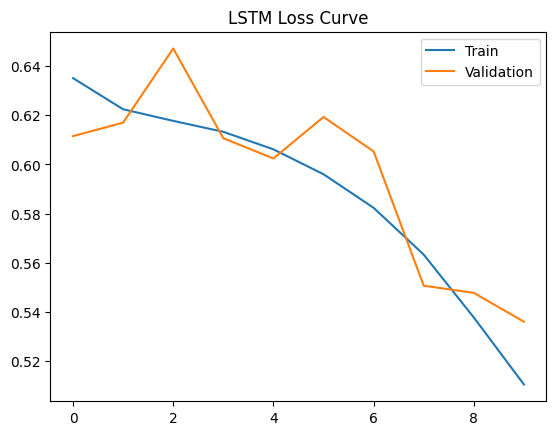

In [64]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("LSTM Loss Curve")
plt.show()



**GRU**

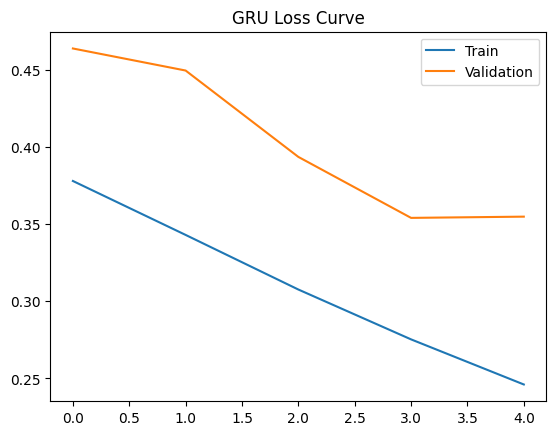

In [65]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("GRU Loss Curve")
plt.show()

**Bi-LSTM**

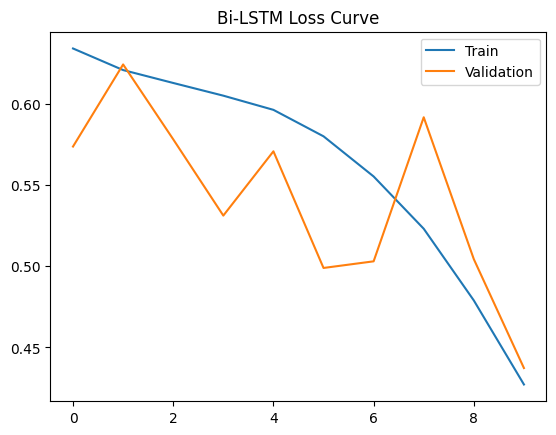

In [66]:
plt.plot(history_bilstm.history['loss'])
plt.plot(history_bilstm.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Bi-LSTM Loss Curve")
plt.show()

Although GRU achieved the highest accuracy, LSTM provided better recall for deterioration detection. Since missing a deteriorating patient is more dangerous than generating a false alarm, recall was prioritized over accuracy.

**Generation 3 (ClinicalBERT)**

In [67]:
print(df.columns)

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age',
       'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel'],
      dtype='object')


The selected sepsis dataset did not contain free-text clinical notes. Therefore, BioClinicalBERT was demonstrated using sample clinical narratives to illustrate transformer-based deterioration prediction.

In [68]:
!pip install transformers torch -q

In [69]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

**Load Model:**

In [70]:
model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Sample Clinical Notes

In [71]:
notes = [
    "Patient has fever, tachycardia, hypotension and suspected sepsis.",
    "Patient stable, normal oxygen saturation and normal heart rate.",
    "Respiratory distress with elevated temperature and low blood pressure."
]

In [72]:
inputs = tokenizer(
    notes,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

Inference

In [73]:
outputs = model(**inputs)

print(outputs.logits)

tensor([[ 1.6353e-04, -9.4173e-01],
        [ 8.8191e-02, -7.7923e-01],
        [-3.2912e-02, -1.0146e+00]], grad_fn=<AddmmBackward0>)
